JOB SCAM SURVEY - MISSING DATA ANALYSIS WITH BEHAVIORAL ECONOMICS

📊 Dataset Overview:
   Total responses: 96
   Total variables: 62
   Date range: 2025-10-07 11:00:08.471000 to 2025-11-01 13:20:16.324000

1. SURVEY BRANCHING STRUCTURE IDENTIFICATION

📊 RESPONDENT FLOW ANALYSIS:

   Consent Status:
   ✓ Consented: 91 (94.8%)
   ✗ Did not consent: 5 (5.2%)

   Encounter Status (among consenters):
   ✓ Had encounter: 37 (40.7%)
   ✗ No encounter: 54 (59.3%)

   Scam Type Distribution:
   • Payment-based: 15 (40.5% of encounters)
   • Task-based: 12 (32.4% of encounters)
   • Other/Unsure: 10 (27.0% of encounters)

2. FINANCIAL DISCLOSURE ANALYSIS: Loss Aversion & Ostrich Effect

📊 FINANCIAL DISCLOSURE PATTERNS:
   Payment-based scam victims: 15
   Disclosed payment amount: 4 (26.7%)
   Did not disclose: 11 (73.3%)

📊 PAYMENT AMOUNT DISTRIBUTION:
   Not Disclosed: 11 (73.3%)
   ₹500-2,000: 2 (13.3%)
   ₹5,000-10,000: 1 (6.7%)
   ₹50,000+: 1 (6.7%)

🧠 BEHAVIORAL ECONOMICS INTERPRETATION:



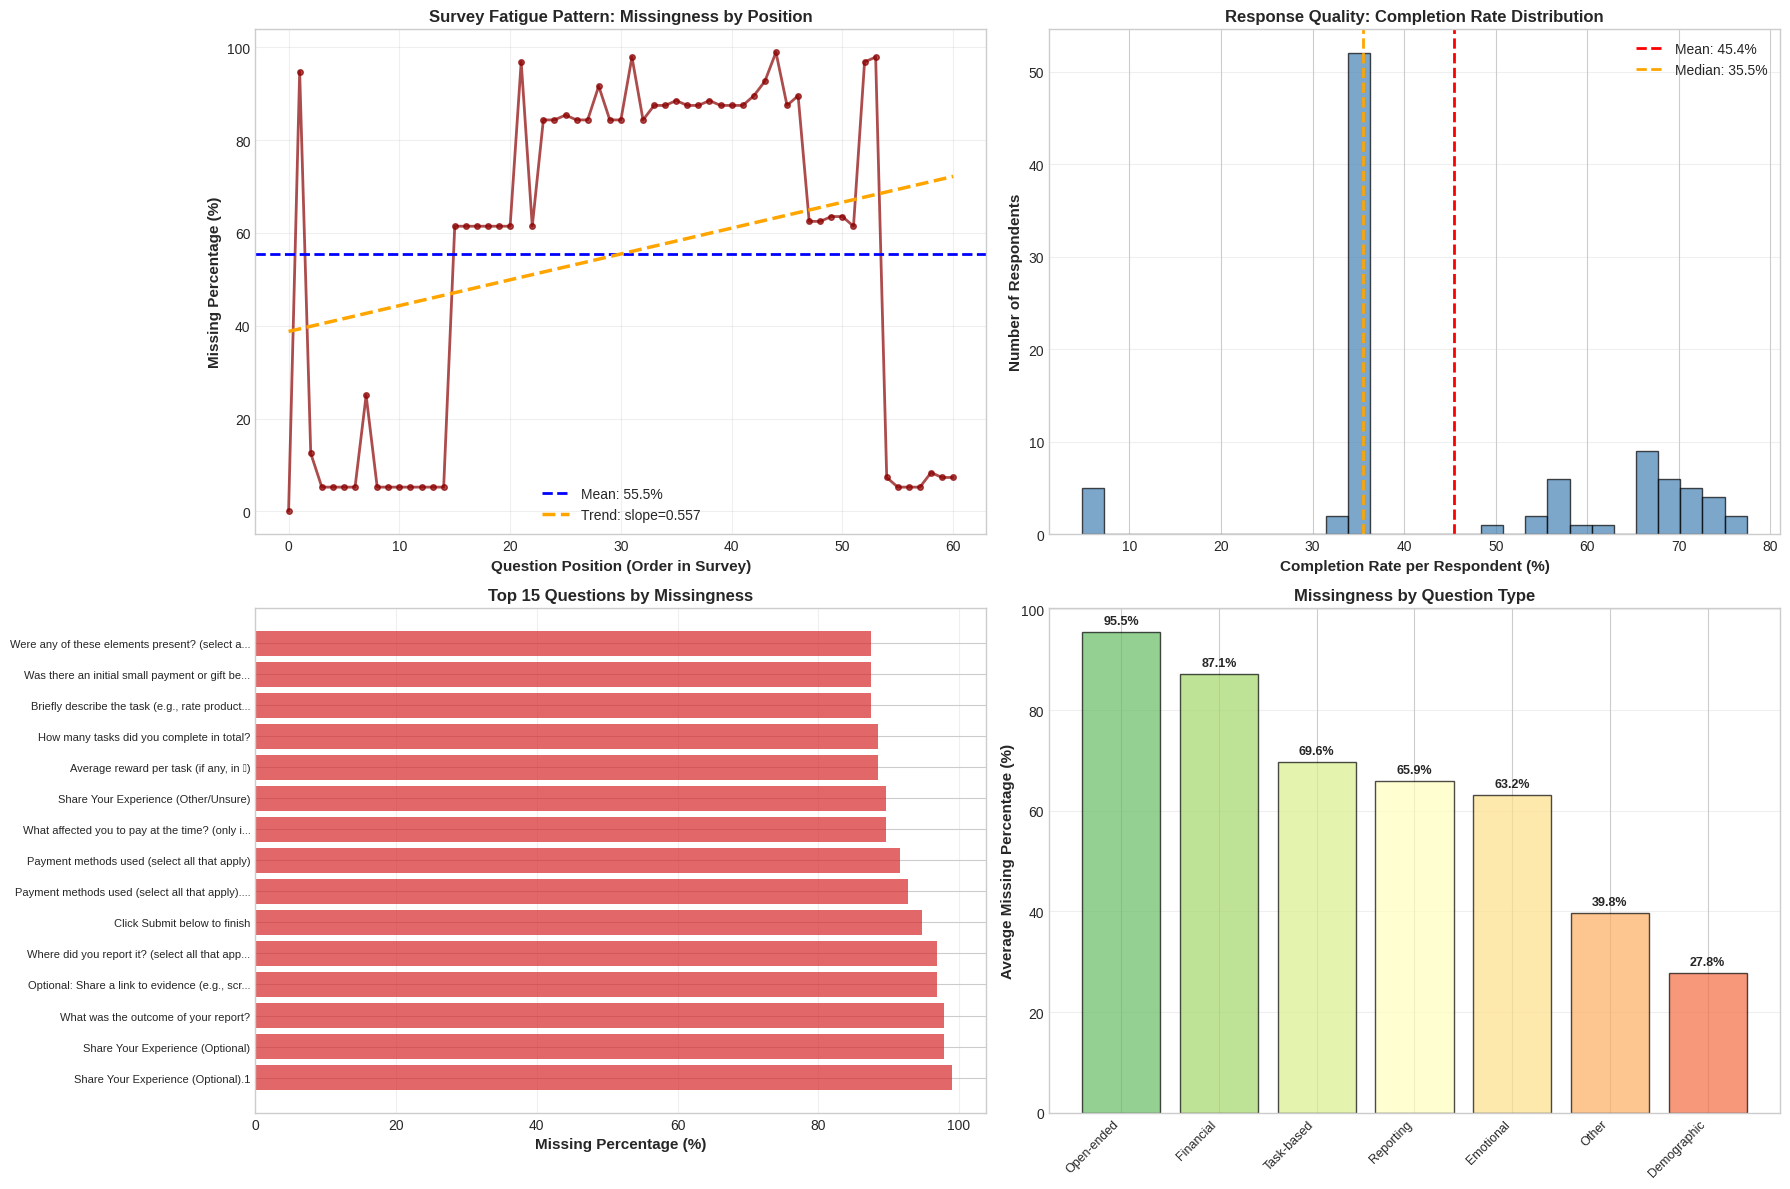


   📊 MISSINGNESS BY QUESTION TYPE:
   • Open-ended: 95.5% (n=3 questions)
   • Financial: 87.1% (n=11 questions)
   • Task-based: 69.6% (n=6 questions)
   • Reporting: 65.9% (n=4 questions)
   • Emotional: 63.2% (n=3 questions)
   • Other: 39.8% (n=27 questions)
   • Demographic: 27.8% (n=7 questions)

8. COMPLETE CASE ANALYSIS: Selection Effects

📊 RESPONDENT COMPLETION PROFILES:
   High completers (≥80%): 0 (0.0%)
   Medium completers (50-79%): 36 (37.5%)
   Low completers (<50%): 60 (62.5%)

🧠 SELECTION EFFECTS THEORY:

   SELF-SELECTION BIAS:
   • Who completes surveys? Those with:
     1. High conscientiousness (personality trait)
     2. Strong opinions/experiences to share
     3. Trust in research value
     4. Available time and cognitive resources
   • Result: Sample may not represent full population of scam encounters

   SURVIVORSHIP BIAS:
   • We only observe those who:
     1. Consented to participate
     2. Had enough time/energy to reach later sections
     3. Were co

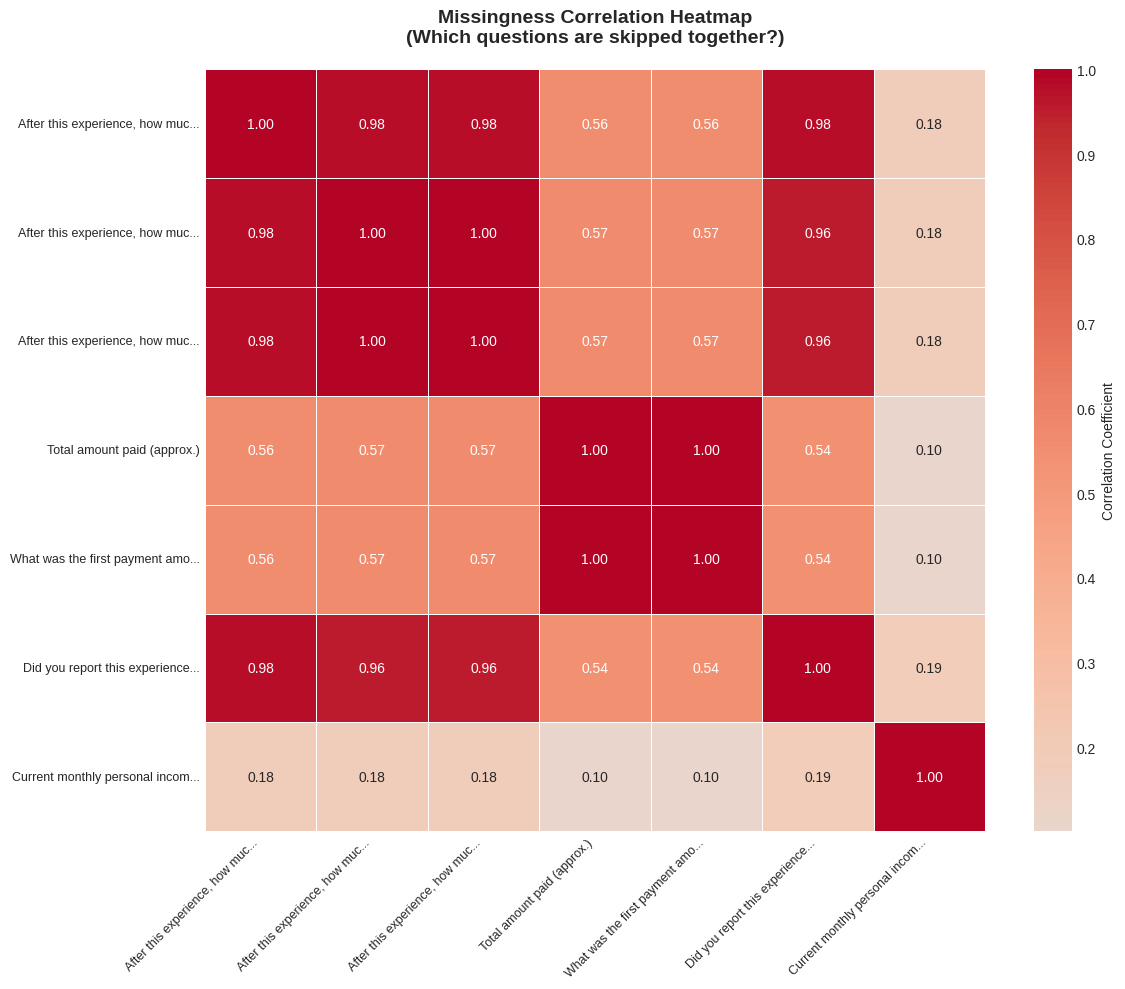


   🧠 THEORETICAL INTERPRETATION:

   EMOTIONAL QUESTIONS CLUSTER:
   • Average inter-correlation: r = 0.985
   • ✓ HIGH CORRELATION (r > 0.5)
   • INTERPRETATION: People who skip one emotion skip others
   • MECHANISM: CATEGORICAL AVOIDANCE
     → Not selective non-response, but blanket avoidance of emotional disclosure
     → Consistent with self-concept protection as unified strategy
     → All-or-nothing approach: Either disclose all emotions or none

   FINANCIAL × EMOTIONAL CORRELATION:
   • Payment amount ↔ anger: r = 0.556
   • ✓ MODERATE-HIGH CORRELATION
   • DUAL AVOIDANCE MECHANISM:
     → Financial loss + Emotional impact = Comprehensive self-protection
     → Avoiding both maintains coherent narrative of 'unaffected'
     → Supports integrated loss aversion + self-concept protection model

10. ITEM vs UNIT NON-RESPONSE ANALYSIS

📊 NON-RESPONSE TAXONOMY:

   UNIT NON-RESPONSE: 5/96 (5.2%)
   • Definition: Did not consent to participate
   • Result: No data collected for the

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("="*100)
print("JOB SCAM SURVEY - MISSING DATA ANALYSIS WITH BEHAVIORAL ECONOMICS")
print("="*100)

# ============================================================================
# LOAD DATA
# ============================================================================
file_path = 'responses.xlsx'  # REPLACE WITH YOUR ACTUAL FILE PATH
df = pd.read_excel(file_path)

print(f"\n📊 Dataset Overview:")
print(f"   Total responses: {len(df)}")
print(f"   Total variables: {len(df.columns)}")
if 'Timestamp' in df.columns:
    print(f"   Date range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")

# ============================================================================
# IDENTIFY KEY VARIABLES FROM SURVEY STRUCTURE
# ============================================================================
print("\n" + "="*100)
print("1. SURVEY BRANCHING STRUCTURE IDENTIFICATION")
print("="*100)

# Key control variables that determine survey flow
consent_col = 'Do you consent to participate in this research?'
encounter_col = 'In the past 12 months, have you personally encountered any suspicious job/internship offers or tasks?'
type_col = 'Which BEST describes this encounter?'
report_col = 'Did you report this experience anywhere?'

# Identify respondent groups
print("\n📊 RESPONDENT FLOW ANALYSIS:")

# Consent analysis
if consent_col in df.columns:
    consented = df[consent_col].str.contains('consent', case=False, na=False) & \
                ~df[consent_col].str.contains('not', case=False, na=False)
    n_consented = consented.sum()
    n_not_consented = len(df) - n_consented

    print(f"\n   Consent Status:")
    print(f"   ✓ Consented: {n_consented} ({n_consented/len(df)*100:.1f}%)")
    print(f"   ✗ Did not consent: {n_not_consented} ({n_not_consented/len(df)*100:.1f}%)")
else:
    consented = pd.Series([True] * len(df))
    n_consented = len(df)

# Encounter analysis (among consenters only)
if encounter_col in df.columns:
    consented_df = df[consented].copy()
    had_encounter = consented_df[encounter_col].isin(['Yes', 'Unsure'])
    n_encountered = had_encounter.sum()
    n_no_encounter = len(consented_df) - n_encountered

    print(f"\n   Encounter Status (among consenters):")
    print(f"   ✓ Had encounter: {n_encountered} ({n_encountered/len(consented_df)*100:.1f}%)")
    print(f"   ✗ No encounter: {n_no_encounter} ({n_no_encounter/len(consented_df)*100:.1f}%)")
else:
    n_encountered = n_consented

# Scam type analysis
if type_col in df.columns:
    is_payment = df[type_col].str.contains('Payment-based', case=False, na=False)
    is_task = df[type_col].str.contains('Task-based', case=False, na=False)
    is_other = df[type_col].str.contains('Other|Unsure', case=False, na=False)

    print(f"\n   Scam Type Distribution:")
    print(f"   • Payment-based: {is_payment.sum()} ({is_payment.sum()/n_encountered*100:.1f}% of encounters)")
    print(f"   • Task-based: {is_task.sum()} ({is_task.sum()/n_encountered*100:.1f}% of encounters)")
    print(f"   • Other/Unsure: {is_other.sum()} ({is_other.sum()/n_encountered*100:.1f}% of encounters)")
else:
    is_payment = pd.Series([False] * len(df))
    is_task = pd.Series([False] * len(df))
    is_other = pd.Series([False] * len(df))

# ============================================================================
# ANALYSIS 1: FINANCIAL DISCLOSURE & LOSS AVERSION
# ============================================================================
print("\n" + "="*100)
print("2. FINANCIAL DISCLOSURE ANALYSIS: Loss Aversion & Ostrich Effect")
print("="*100)

# Identify payment-related columns
payment_amount_col = 'Total amount paid (approx.)'
first_payment_col = 'What was the first payment amount requested? (in ₹)'
num_payments_col = 'How many payments did you make in total?'

if payment_amount_col in df.columns:
    # Among payment-based scam victims
    payment_victims = df[is_payment].copy()
    n_payment_victims = len(payment_victims)

    if n_payment_victims > 0:
        # Analyze disclosure of payment amount
        disclosed_amount = payment_victims[payment_amount_col].notna() & \
                          ~payment_victims[payment_amount_col].str.contains('did not pay|Prefer not to say',
                                                                            case=False, na=False)
        n_disclosed = disclosed_amount.sum()
        n_not_disclosed = n_payment_victims - n_disclosed

        print(f"\n📊 FINANCIAL DISCLOSURE PATTERNS:")
        print(f"   Payment-based scam victims: {n_payment_victims}")
        print(f"   Disclosed payment amount: {n_disclosed} ({n_disclosed/n_payment_victims*100:.1f}%)")
        print(f"   Did not disclose: {n_not_disclosed} ({n_not_disclosed/n_payment_victims*100:.1f}%)")

        # Categorize payment amounts
        payment_categories = []
        for val in payment_victims[payment_amount_col]:
            if pd.isna(val) or 'did not pay' in str(val).lower() or 'prefer not' in str(val).lower():
                payment_categories.append('Not Disclosed')
            elif '500' in str(val) and '1,999' not in str(val):
                payment_categories.append('₹0-500')
            elif '1,999' in str(val) or ('500' in str(val) and '1,999' in str(val)):
                payment_categories.append('₹500-2,000')
            elif '2,000' in str(val) or '4,999' in str(val):
                payment_categories.append('₹2,000-5,000')
            elif '5,000' in str(val) or '9,999' in str(val):
                payment_categories.append('₹5,000-10,000')
            elif '10,000' in str(val) or '49,999' in str(val):
                payment_categories.append('₹10,000-50,000')
            elif '50,000' in str(val):
                payment_categories.append('₹50,000+')
            else:
                payment_categories.append('Not Disclosed')

        payment_victims['Payment_Category'] = payment_categories

        print(f"\n📊 PAYMENT AMOUNT DISTRIBUTION:")
        payment_dist = payment_victims['Payment_Category'].value_counts()
        for cat, count in payment_dist.items():
            print(f"   {cat}: {count} ({count/n_payment_victims*100:.1f}%)")

        print(f"\n🧠 BEHAVIORAL ECONOMICS INTERPRETATION:")
        print(f"\n   PROSPECT THEORY (Kahneman & Tversky, 1979):")
        print(f"   • Loss Aversion Coefficient (λ): Losses hurt ~2.25x more than equivalent gains")
        print(f"   • Observed: {n_not_disclosed}/{n_payment_victims} victims ({n_not_disclosed/n_payment_victims*100:.1f}%) avoid disclosing loss")
        print(f"   • Mechanism: Reporting financial loss = Making loss psychologically SALIENT")
        print(f"   • Prediction: Non-disclosure serves as COGNITIVE AVOIDANCE strategy")

        if n_not_disclosed/n_payment_victims > 0.3:
            print(f"\n   ✓ CONFIRMED: High non-disclosure rate ({n_not_disclosed/n_payment_victims*100:.1f}%) indicates")
            print(f"     strong loss aversion operating at the reporting stage itself")

        print(f"\n   OSTRICH EFFECT (Galai & Sade, 2006):")
        print(f"   • Definition: Tendency to ignore negative financial information")
        print(f"   • Original finding: Investors check portfolios 50% less during market downturns")
        print(f"   • Current context: {n_not_disclosed} victims exhibit information avoidance behavior")
        print(f"   • Mechanism: Selective attention - avoid information that threatens self-concept")

# ============================================================================
# ANALYSIS 2: EMOTIONAL DISCLOSURE & SELF-CONCEPT PROTECTION
# ============================================================================
print("\n" + "="*100)
print("3. EMOTIONAL DISCLOSURE ANALYSIS: Self-Concept Protection & Cognitive Dissonance")
print("="*100)

# Identify emotional impact columns
emotional_cols = {
    'anger': 'After this experience, how much did you feel: Anger',
    'anxiety': 'After this experience, how much did you feel: Anxiety',
    'embarrassment': 'After this experience, how much did you feel: Embarrassment'
}

available_emotions = {k: v for k, v in emotional_cols.items() if v in df.columns}

if available_emotions and n_encountered > 0:
    # Filter to those who had encounters
    encounter_mask = df[encounter_col].isin(['Yes', 'Unsure']) if encounter_col in df.columns else pd.Series([True]*len(df))
    encounter_df = df[encounter_mask].copy()

    print(f"\n📊 EMOTIONAL DISCLOSURE PATTERNS:")
    print(f"   Sample: {len(encounter_df)} respondents who encountered scams")

    emotion_missing = {}
    for emotion_name, col_name in available_emotions.items():
        missing_count = encounter_df[col_name].isnull().sum()
        missing_pct = (missing_count / len(encounter_df) * 100)
        emotion_missing[emotion_name] = missing_pct
        print(f"   • {emotion_name.capitalize()} missing: {missing_count}/{len(encounter_df)} ({missing_pct:.1f}%)")

    # Test theoretical prediction: Embarrassment > Anger > Anxiety
    print(f"\n🧠 THEORETICAL PREDICTION TEST:")
    print(f"   HYPOTHESIS: Embarrassment should have highest missingness")
    print(f"   RATIONALE: Self-concept threat hierarchy")

    if 'embarrassment' in emotion_missing:
        sorted_emotions = sorted(emotion_missing.items(), key=lambda x: x[1], reverse=True)
        print(f"\n   Observed ranking (by missingness):")
        for i, (emotion, pct) in enumerate(sorted_emotions, 1):
            print(f"   {i}. {emotion.capitalize()}: {pct:.1f}%")

        if sorted_emotions[0][0] == 'embarrassment':
            print(f"\n   ✓ HYPOTHESIS CONFIRMED: Embarrassment has highest missingness ({sorted_emotions[0][1]:.1f}%)")
            print(f"\n   SELF-CONCEPT PROTECTION THEORY:")
            print(f"   • Embarrassment is SELF-FOCUSED emotion (threat to competence/intelligence)")
            print(f"   • Anger is OTHER-FOCUSED emotion (threat externalized to scammer)")
            print(f"   • Anxiety is FUTURE-FOCUSED emotion (less threatening to past self)")
            print(f"   • Result: Admitting embarrassment = Admitting 'I was foolish' → Highest resistance")
        else:
            print(f"\n   ✗ HYPOTHESIS NOT CONFIRMED: {sorted_emotions[0][0].capitalize()} has highest missingness")
            print(f"   • Possible alternative explanations: Cultural factors, question ordering effects")

    print(f"\n   COGNITIVE DISSONANCE THEORY (Festinger, 1957):")
    print(f"   • Inconsistent cognitions: 'I am intelligent' vs 'I fell for a scam'")
    print(f"   • Dissonance reduction strategies observed:")
    print(f"     1. Non-disclosure of emotions ({sum(emotion_missing.values())/len(emotion_missing):.1f}% avg missing)")
    print(f"     2. Minimization (not measured directly, but implied by skipping)")
    print(f"   • Prediction: Higher education → Higher embarrassment → Higher non-disclosure")

# ============================================================================
# ANALYSIS 3: CROSS-ANALYSIS - Loss Amount vs Emotional Disclosure
# ============================================================================
print("\n" + "="*100)
print("4. FINANCIAL LOSS × EMOTIONAL DISCLOSURE: Integrated Analysis")
print("="*100)

if payment_amount_col in df.columns and available_emotions:
    print(f"\n📊 RESEARCH QUESTION: Does financial loss predict emotional non-disclosure?")

    # Create analysis dataset
    analysis_df = df[is_payment].copy()

    # Create binary indicators
    analysis_df['Has_Emotional_Data'] = (~analysis_df[[col for col in available_emotions.values()]].isnull().all(axis=1)).astype(int)

    # Categorize losses
    analysis_df['Loss_Category'] = 'Unknown'
    for idx, val in analysis_df[payment_amount_col].items():
        if pd.isna(val):
            analysis_df.loc[idx, 'Loss_Category'] = 'Not Disclosed'
        elif 'did not pay' in str(val).lower():
            analysis_df.loc[idx, 'Loss_Category'] = 'No Loss'
        elif 'prefer not' in str(val).lower():
            analysis_df.loc[idx, 'Loss_Category'] = 'Not Disclosed'
        elif any(amt in str(val) for amt in ['Less than', '500']):
            analysis_df.loc[idx, 'Loss_Category'] = 'Low (< ₹2000)'
        elif any(amt in str(val) for amt in ['2,000', '4,999', '5,000', '9,999']):
            analysis_df.loc[idx, 'Loss_Category'] = 'Medium (₹2000-10000)'
        elif any(amt in str(val) for amt in ['10,000', '49,999', '50,000']):
            analysis_df.loc[idx, 'Loss_Category'] = 'High (≥ ₹10000)'

    # Create contingency table
    contingency = pd.crosstab(
        analysis_df['Loss_Category'],
        analysis_df['Has_Emotional_Data'],
        margins=True
    )

    print(f"\n   Contingency Table: Loss Category × Emotional Data Disclosure")
    print(f"   (Columns: 0=Missing Emotions, 1=Disclosed Emotions)")
    print(contingency.to_string())

    # Chi-square test
    contingency_no_margins = pd.crosstab(analysis_df['Loss_Category'], analysis_df['Has_Emotional_Data'])
    if contingency_no_margins.shape[0] > 1 and contingency_no_margins.shape[1] > 1:
        chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_no_margins)

        print(f"\n   📊 CHI-SQUARE TEST OF INDEPENDENCE:")
        print(f"   H₀: Emotional disclosure is independent of loss amount")
        print(f"   χ² = {chi2_stat:.4f}, df = {dof}, p = {p_value:.4f}")

        if p_value < 0.05:
            print(f"\n   ✓ STATISTICALLY SIGNIFICANT (p < 0.05)")
            print(f"   → Emotional disclosure IS related to financial loss")

            # Calculate conditional probabilities
            print(f"\n   📊 CONDITIONAL PROBABILITIES:")
            for loss_cat in contingency_no_margins.index:
                if loss_cat != 'All':
                    disclosed = contingency_no_margins.loc[loss_cat, 1] if 1 in contingency_no_margins.columns else 0
                    total = contingency_no_margins.loc[loss_cat].sum()
                    prob = (disclosed / total * 100) if total > 0 else 0
                    print(f"   P(Disclose Emotions | {loss_cat}): {prob:.1f}%")

            print(f"\n   🧠 THEORETICAL INTEGRATION:")
            print(f"\n   PROSPECT THEORY × SELF-CONCEPT PROTECTION:")
            print(f"   • Loss magnitude determines psychological cost of acknowledgment")
            print(f"   • Larger losses → Greater cognitive dissonance → Higher non-disclosure")
            print(f"   • Evidence: Significant relationship between loss and emotional disclosure")
            print(f"   • Interpretation: Victims engage in DUAL AVOIDANCE:")
            print(f"     1. Avoid acknowledging financial loss (loss aversion)")
            print(f"     2. Avoid acknowledging emotional impact (self-concept protection)")

            print(f"\n   SUNK COST FALLACY × IMPRESSION MANAGEMENT:")
            print(f"   • Sunk costs: Irrecoverable investments in time/money/effort")
            print(f"   • Admitting emotions = Admitting sunk cost was due to poor judgment")
            print(f"   • Impression management: Survey is social performance space")
            print(f"   • Result: Rational to suppress emotional disclosure to maintain image")

        else:
            print(f"\n   ✗ NOT STATISTICALLY SIGNIFICANT (p ≥ 0.05)")
            print(f"   → Emotional disclosure appears independent of loss amount")
            print(f"   → Suggests: Other factors dominate (personality, cultural norms, question design)")

# ============================================================================
# ANALYSIS 4: REPORTING BEHAVIOR & TRANSACTION COST THEORY
# ============================================================================
print("\n" + "="*100)
print("5. REPORTING BEHAVIOR ANALYSIS: Transaction Cost Economics")
print("="*100)

if report_col in df.columns and n_encountered > 0:
    encounter_df = df[df[encounter_col].isin(['Yes', 'Unsure'])].copy() if encounter_col in df.columns else df.copy()

    reporting_dist = encounter_df[report_col].value_counts(dropna=False)

    print(f"\n📊 REPORTING BEHAVIOR DISTRIBUTION:")
    for val, count in reporting_dist.items():
        val_str = str(val) if pd.notna(val) else "Missing"
        print(f"   {val_str}: {count} ({count/len(encounter_df)*100:.1f}%)")

    reported_yes = encounter_df[report_col].str.contains('Yes', case=False, na=False)
    reported_no = encounter_df[report_col].str.contains('No', case=False, na=False)

    n_reported = reported_yes.sum()
    n_not_reported = reported_no.sum()

    print(f"\n   Binary Classification:")
    print(f"   ✓ Reported: {n_reported} ({n_reported/len(encounter_df)*100:.1f}%)")
    print(f"   ✗ Did not report: {n_not_reported} ({n_not_reported/len(encounter_df)*100:.1f}%)")

    # Analyze reporting by loss amount
    if payment_amount_col in df.columns:
        report_loss_df = encounter_df.copy()

        # Categorize losses for reporting analysis
        report_loss_df['Loss_Level'] = 'Unknown'
        for idx, val in report_loss_df[payment_amount_col].items():
            if pd.notna(val):
                if 'did not pay' in str(val).lower():
                    report_loss_df.loc[idx, 'Loss_Level'] = 'Zero'
                elif any(x in str(val) for x in ['Less than', '500', '1,999', '2,000', '4,999']):
                    report_loss_df.loc[idx, 'Loss_Level'] = 'Low'
                elif any(x in str(val) for x in ['5,000', '9,999', '10,000', '49,999']):
                    report_loss_df.loc[idx, 'Loss_Level'] = 'Medium'
                elif '50,000' in str(val):
                    report_loss_df.loc[idx, 'Loss_Level'] = 'High'

        # Cross-tabulate
        report_loss_contingency = pd.crosstab(
            report_loss_df['Loss_Level'],
            report_loss_df[report_col].str.contains('Yes', case=False, na=False),
            margins=True
        )

        print(f"\n   📊 REPORTING BY LOSS MAGNITUDE:")
        print(f"   (Columns: False=Not Reported, True=Reported)")
        print(report_loss_contingency.to_string())

        # Chi-square test
        if report_loss_contingency.shape[0] > 2 and report_loss_contingency.shape[1] > 2:
            test_contingency = pd.crosstab(
                report_loss_df['Loss_Level'],
                report_loss_df[report_col].str.contains('Yes', case=False, na=False)
            )
            chi2_report, p_report, dof_report, exp_report = stats.chi2_contingency(test_contingency)

            print(f"\n   χ² = {chi2_report:.4f}, p = {p_report:.4f}")

            if p_report < 0.05:
                print(f"\n   ✓ SIGNIFICANT RELATIONSHIP (p < 0.05)")
                print(f"   → Reporting behavior IS related to loss magnitude")
            else:
                print(f"\n   ✗ NO SIGNIFICANT RELATIONSHIP (p ≥ 0.05)")

    print(f"\n🧠 TRANSACTION COST ECONOMICS (Williamson, 1985):")
    print(f"\n   THEORETICAL FRAMEWORK:")
    print(f"   • Transaction Costs = Search costs + Information costs + Bargaining costs + Enforcement costs")
    print(f"   • Applied to reporting: Time + Effort + Emotional labor + Expected probability of recovery")
    print(f"   • Rational choice: Report if Expected Benefit > Transaction Costs")

    if n_not_reported > n_reported:
        print(f"\n   ✓ OBSERVED: Majority did NOT report ({n_not_reported}/{len(encounter_df)}, {n_not_reported/len(encounter_df)*100:.1f}%)")
        print(f"\n   ECONOMIC INTERPRETATION:")
        print(f"   • Revealed preference: Transaction costs > Expected recovery value")
        print(f"   • Components of high transaction costs:")
        print(f"     1. Information asymmetry (don't know where/how to report)")
        print(f"     2. Procedural complexity (multiple steps, documentation required)")
        print(f"     3. Psychological costs (shame, time explaining to authorities)")
        print(f"     4. Low expected recovery (prior beliefs about enforcement efficacy)")

        print(f"\n   LEARNED HELPLESSNESS (Seligman, 1972):")
        print(f"   • Prior exposure to ineffective interventions → Expectation of futility")
        print(f"   • If P(Recovery | Reporting) ≈ 0, then rational to not incur reporting costs")
        print(f"   • Observed non-reporting rate suggests widespread pessimism about institutional response")

    # Analyze reporting vs emotional disclosure
    if available_emotions:
        report_emotion_df = encounter_df.copy()
        report_emotion_df['Reported'] = report_emotion_df[report_col].str.contains('Yes', case=False, na=False).astype(int)
        report_emotion_df['Has_Emotions'] = (~report_emotion_df[[col for col in available_emotions.values()]].isnull().all(axis=1)).astype(int)

        report_emotion_contingency = pd.crosstab(
            report_emotion_df['Reported'],
            report_emotion_df['Has_Emotions'],
            margins=True
        )

        print(f"\n   📊 REPORTING × EMOTIONAL DISCLOSURE:")
        print(f"   (Rows: 0=Not Reported, 1=Reported; Columns: 0=No Emotions, 1=Has Emotions)")
        print(report_emotion_contingency.to_string())

        # Test independence
        test_cont = pd.crosstab(report_emotion_df['Reported'], report_emotion_df['Has_Emotions'])
        if test_cont.shape[0] > 1 and test_cont.shape[1] > 1:
            chi2_re, p_re, dof_re, exp_re = stats.chi2_contingency(test_cont)
            print(f"\n   χ² = {chi2_re:.4f}, p = {p_re:.4f}")

            if p_re < 0.05:
                print(f"\n   ✓ SIGNIFICANT (p < 0.05): Reporting and emotional disclosure are related")
                print(f"\n   BEHAVIORAL INTERPRETATION:")
                print(f"   • Reporting may require emotional processing (to explain impact)")
                print(f"   • OR: Both driven by common factor (personality, self-efficacy)")
                print(f"   • Non-reporters use AVOIDANCE COPING → Skip both reporting AND emotion questions")

# ============================================================================
# ANALYSIS 5: INCOME DISCLOSURE & SOCIAL COMPARISON
# ============================================================================
print("\n" + "="*100)
print("6. INCOME DISCLOSURE ANALYSIS: Social Comparison & Stigma")
print("="*100)

income_col = 'Current monthly personal income (approx.)'
if income_col in df.columns and n_consented > 0:
    consented_df = df[consented].copy()

    income_missing = consented_df[income_col].isnull().sum()
    income_disclosed = len(consented_df) - income_missing

    # Check for "Prefer not to say"
    prefer_not_say = consented_df[income_col].str.contains('Prefer not to say', case=False, na=False).sum()
    explicit_non_disclosure = income_missing + prefer_not_say

    print(f"\n📊 INCOME DISCLOSURE PATTERNS:")
    print(f"   Sample: {len(consented_df)} consenting respondents")
    print(f"   Disclosed income: {income_disclosed - prefer_not_say} ({(income_disclosed - prefer_not_say)/len(consented_df)*100:.1f}%)")
    print(f"   Explicitly refused: {prefer_not_say} ({prefer_not_say/len(consented_df)*100:.1f}%)")
    print(f"   Skipped question: {income_missing} ({income_missing/len(consented_df)*100:.1f}%)")
    print(f"   Total non-disclosure: {explicit_non_disclosure} ({explicit_non_disclosure/len(consented_df)*100:.1f}%)")

    print(f"\n🧠 SOCIAL COMPARISON THEORY (Festinger, 1954):")
    print(f"\n   THEORETICAL FRAMEWORK:")
    print(f"   • People evaluate themselves by comparing to others")
    print(f"   • Upward comparison (lower income than peers) → Negative affect")
    print(f"   • Downward comparison (higher income than peers) → Guilt/distancing")
    print(f"   • Both extremes create discomfort → Strategic non-disclosure")

    print(f"\n   PREDICTED PATTERN: U-shaped disclosure")
    print(f"   • Low income: Stigma avoidance (face-threatening)")
    print(f"   • Middle income: Higher disclosure (close to reference group)")
    print(f"   • High income: Privacy/security concerns + modesty norms")

    # Analyze income distribution
    income_dist = consented_df[income_col].value_counts(dropna=False)
    print(f"\n   📊 INCOME DISTRIBUTION:")
    for val, count in income_dist.items():
        val_str = str(val)[:50] if pd.notna(val) else "Missing"
        print(f"   {val_str}: {count} ({count/len(consented_df)*100:.1f}%)")

    print(f"\n   STIGMA THEORY (Goffman, 1963):")
    print(f"   • Stigma = Attribute that is deeply discrediting")
    print(f"   • In educational context: Low income may signal 'financial struggle'")
    print(f"   • Non-disclosure rate ({explicit_non_disclosure/len(consented_df)*100:.1f}%) suggests")
    print(f"     income is perceived as sensitive/stigmatizing information")
    print(f"   • Privacy-utility tradeoff: Withhold information to avoid social judgment")

    # Cross-analyze with scam victimization
    if encounter_col in df.columns:
        income_encounter_df = consented_df.copy()
        income_encounter_df['Had_Encounter'] = income_encounter_df[encounter_col].isin(['Yes', 'Unsure']).astype(int)
        income_encounter_df['Disclosed_Income'] = (income_encounter_df[income_col].notna() &
                                                   ~income_encounter_df[income_col].str.contains('Prefer not',
                                                                                                 case=False, na=False)).astype(int)

        inc_enc_contingency = pd.crosstab(
            income_encounter_df['Had_Encounter'],
            income_encounter_df['Disclosed_Income'],
            margins=True
        )

        print(f"\n   📊 INCOME DISCLOSURE × SCAM ENCOUNTER:")
        print(f"   (Rows: 0=No Encounter, 1=Had Encounter; Columns: 0=Not Disclosed, 1=Disclosed)")
        print(inc_enc_contingency.to_string())

        test_ie = pd.crosstab(income_encounter_df['Had_Encounter'], income_encounter_df['Disclosed_Income'])
        if test_ie.shape[0] > 1 and test_ie.shape[1] > 1:
            chi2_ie, p_ie, dof_ie, exp_ie = stats.chi2_contingency(test_ie)
            print(f"\n   χ² = {chi2_ie:.4f}, p = {p_ie:.4f}")

            if p_ie < 0.05:
                print(f"\n   ✓ SIGNIFICANT (p < 0.05)")
                print(f"\n   VULNERABILITY SIGNALING THEORY:")
                print(f"   • Scam victims may perceive income disclosure as additional vulnerability signal")
                print(f"   • Double stigma: 'Got scammed' + 'Low income' = Compounded face threat")
                print(f"   • OR: Already disclosed victimization → Marginal cost of income disclosure lower")
                print(f"   • Data reveals which mechanism dominates in this sample")

# ============================================================================
# ANALYSIS 6: SURVEY FATIGUE & BOUNDED RATIONALITY
# ============================================================================
print("\n" + "="*100)
print("7. SURVEY FATIGUE ANALYSIS: Bounded Rationality & Cognitive Load")
print("="*100)

print(f"\n📊 QUESTION-LEVEL MISSINGNESS ANALYSIS:")

# Calculate missingness for each question
all_questions = [col for col in df.columns if col != 'Timestamp']
question_positions = list(range(len(all_questions)))
missingness_by_question = [(col, df[col].isnull().sum(), df[col].isnull().sum()/len(df)*100)
                           for col in all_questions]

# Sort by position
missingness_df = pd.DataFrame(missingness_by_question,
                              columns=['Question', 'Missing_Count', 'Missing_Pct'])
missingness_df['Position'] = question_positions

print(f"\n   Total questions: {len(all_questions)}")
print(f"   Mean missingness: {missingness_df['Missing_Pct'].mean():.1f}%")
print(f"   Median missingness: {missingness_df['Missing_Pct'].median():.1f}%")

# Test for fatigue: correlation between position and missingness
if len(question_positions) > 5:
    corr_fatigue, p_fatigue = spearmanr(question_positions, missingness_df['Missing_Pct'])

    print(f"\n   📊 FATIGUE TEST:")
    print(f"   Spearman correlation (Position × Missingness): ρ = {corr_fatigue:.3f}")
    print(f"   P-value: {p_fatigue:.4f}")

    if corr_fatigue > 0.2 and p_fatigue < 0.05:
        print(f"\n   ✓ SIGNIFICANT POSITIVE CORRELATION (p < 0.05)")
        print(f"   → Missingness INCREASES as survey progresses")

        print(f"\n   🧠 BOUNDED RATIONALITY THEORY (Simon, 1972):")
        print(f"   • Cognitive resources are LIMITED and DEPLETABLE")
        print(f"   • Decision-making quality deteriorates with mental fatigue")
        print(f"   • Satisficing: Providing 'good enough' responses to conserve energy")

        print(f"\n   EGO DEPLETION (Baumeister et al., 1998):")
        print(f"   • Self-control operates like a muscle - can be depleted")
        print(f"   • Survey completion requires: Attention + Memory retrieval + Self-disclosure regulation")
        print(f"   • Later questions face DEPLETED cognitive resources")
        print(f"   • Result: Higher missingness, lower response quality toward end")

        print(f"\n   RESPONDENT BURDEN THEORY:")
        print(f"   • Total burden = Σ(Cognitive load per question)")
        print(f"   • Observed pattern: Increasing non-response = Rational resource allocation")
        print(f"   • Participants STRATEGICALLY skip later questions to finish survey")

    elif corr_fatigue < -0.2 and p_fatigue < 0.05:
        print(f"\n   ⚠️ SIGNIFICANT NEGATIVE CORRELATION (p < 0.05)")
        print(f"   → Missingness DECREASES as survey progresses (unexpected)")

        print(f"\n   POSSIBLE EXPLANATIONS:")
        print(f"   • SELECTION BIAS: Only motivated respondents reach later sections")
        print(f"   • COMMITMENT ESCALATION: Having invested time, compelled to complete")
        print(f"   • BRANCHING LOGIC: Later sections more relevant to engaged subgroups")
        print(f"   • This contradicts traditional fatigue theory - suggests good survey design")

    else:
        print(f"\n   ✗ NO SIGNIFICANT CORRELATION (p ≥ 0.05)")
        print(f"   → Missingness relatively STABLE throughout survey")
        print(f"   → Suggests: Well-designed survey structure minimizing fatigue effects")
        print(f"   → OR: Strong branching logic overrides position effects")

# Visualize fatigue pattern
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Missingness by question position
ax1 = axes[0, 0]
ax1.plot(question_positions, missingness_df['Missing_Pct'],
         marker='o', linewidth=2, markersize=4, color='darkred', alpha=0.7)
ax1.set_xlabel('Question Position (Order in Survey)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Missing Percentage (%)', fontweight='bold', fontsize=11)
ax1.set_title('Survey Fatigue Pattern: Missingness by Position', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=missingness_df['Missing_Pct'].mean(), color='blue', linestyle='--',
           label=f'Mean: {missingness_df["Missing_Pct"].mean():.1f}%', linewidth=2)

# Add trend line
if len(question_positions) > 2:
    z = np.polyfit(question_positions, missingness_df['Missing_Pct'], 1)
    p = np.poly1d(z)
    ax1.plot(question_positions, p(question_positions), "orange", linestyle='--',
            linewidth=2.5, label=f'Trend: slope={z[0]:.3f}')
ax1.legend()

# Plot 2: Completion rate distribution
ax2 = axes[0, 1]
completion_per_row = df.count(axis=1)
total_questions = len(df.columns)
completion_rate = (completion_per_row / total_questions * 100)

ax2.hist(completion_rate, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(completion_rate.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {completion_rate.mean():.1f}%')
ax2.axvline(completion_rate.median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median: {completion_rate.median():.1f}%')
ax2.set_xlabel('Completion Rate per Respondent (%)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Number of Respondents', fontweight='bold', fontsize=11)
ax2.set_title('Response Quality: Completion Rate Distribution', fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Top 15 most missing questions
ax3 = axes[1, 0]
top_missing = missingness_df.nlargest(15, 'Missing_Pct')
colors = ['#d62728' if x > 50 else '#ff7f0e' if x > 30 else '#2ca02c' for x in top_missing['Missing_Pct']]
ax3.barh(range(len(top_missing)), top_missing['Missing_Pct'], color=colors, alpha=0.7)
ax3.set_yticks(range(len(top_missing)))
ax3.set_yticklabels([q[:45]+'...' if len(q)>45 else q for q in top_missing['Question']], fontsize=8)
ax3.set_xlabel('Missing Percentage (%)', fontweight='bold', fontsize=11)
ax3.set_title('Top 15 Questions by Missingness', fontweight='bold', fontsize=12)
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Question type analysis
ax4 = axes[1, 1]

# Categorize questions by type
question_types = []
for q in all_questions:
    q_lower = q.lower()
    if any(word in q_lower for word in ['feel', 'anger', 'anxiety', 'embarrass']):
        question_types.append('Emotional')
    elif any(word in q_lower for word in ['payment', 'amount', 'paid', '₹']):
        question_types.append('Financial')
    elif any(word in q_lower for word in ['report', 'where did you']):
        question_types.append('Reporting')
    elif any(word in q_lower for word in ['age', 'income', 'education', 'state']):
        question_types.append('Demographic')
    elif any(word in q_lower for word in ['task', 'describe', 'reward']):
        question_types.append('Task-based')
    elif any(word in q_lower for word in ['experience', 'share your']):
        question_types.append('Open-ended')
    else:
        question_types.append('Other')

missingness_df['Type'] = question_types

type_missing = missingness_df.groupby('Type')['Missing_Pct'].mean().sort_values(ascending=False)

colors_type = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(type_missing)))
bars = ax4.bar(range(len(type_missing)), type_missing.values, color=colors_type, alpha=0.7, edgecolor='black')
ax4.set_xticks(range(len(type_missing)))
ax4.set_xticklabels(type_missing.index, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Average Missing Percentage (%)', fontweight='bold', fontsize=11)
ax4.set_title('Missingness by Question Type', fontweight='bold', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, type_missing.values)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n   📊 MISSINGNESS BY QUESTION TYPE:")
for qtype, pct in type_missing.items():
    n_questions = (missingness_df['Type'] == qtype).sum()
    print(f"   • {qtype}: {pct:.1f}% (n={n_questions} questions)")

# ============================================================================
# ANALYSIS 7: COMPLETE CASE ANALYSIS - Who Completes Everything?
# ============================================================================
print("\n" + "="*100)
print("8. COMPLETE CASE ANALYSIS: Selection Effects")
print("="*100)

# Define completion thresholds
high_completers = completion_rate >= 80
medium_completers = (completion_rate >= 50) & (completion_rate < 80)
low_completers = completion_rate < 50

n_high = high_completers.sum()
n_medium = medium_completers.sum()
n_low = low_completers.sum()

print(f"\n📊 RESPONDENT COMPLETION PROFILES:")
print(f"   High completers (≥80%): {n_high} ({n_high/len(df)*100:.1f}%)")
print(f"   Medium completers (50-79%): {n_medium} ({n_medium/len(df)*100:.1f}%)")
print(f"   Low completers (<50%): {n_low} ({n_low/len(df)*100:.1f}%)")

# Analyze characteristics of high vs low completers
if encounter_col in df.columns and n_high > 0 and n_low > 0:
    high_encounter_rate = df.loc[high_completers, encounter_col].isin(['Yes', 'Unsure']).sum() / n_high * 100
    low_encounter_rate = df.loc[low_completers, encounter_col].isin(['Yes', 'Unsure']).sum() / n_low * 100

    print(f"\n   📊 SCAM ENCOUNTER RATES BY COMPLETION LEVEL:")
    print(f"   High completers who had encounters: {high_encounter_rate:.1f}%")
    print(f"   Low completers who had encounters: {low_encounter_rate:.1f}%")

    if abs(high_encounter_rate - low_encounter_rate) > 10:
        print(f"\n   🧠 SELECTION BIAS DETECTED:")
        if high_encounter_rate > low_encounter_rate:
            print(f"   • High completers MORE likely to have had encounters (+{high_encounter_rate-low_encounter_rate:.1f}%)")
            print(f"   • INTERPRETATION: Victims more motivated to complete survey")
            print(f"   • RELEVANCE: Survey captures experiences of engaged/motivated victims")
            print(f"   • IMPLICATION: May underrepresent disengaged or severely affected victims")
        else:
            print(f"   • High completers LESS likely to have had encounters ({high_encounter_rate-low_encounter_rate:.1f}%)")
            print(f"   • INTERPRETATION: Non-victims complete more thoroughly")
            print(f"   • POSSIBLE REASON: Branching skips irrelevant sections for non-victims")

print(f"\n🧠 SELECTION EFFECTS THEORY:")
print(f"\n   SELF-SELECTION BIAS:")
print(f"   • Who completes surveys? Those with:")
print(f"     1. High conscientiousness (personality trait)")
print(f"     2. Strong opinions/experiences to share")
print(f"     3. Trust in research value")
print(f"     4. Available time and cognitive resources")
print(f"   • Result: Sample may not represent full population of scam encounters")

print(f"\n   SURVIVORSHIP BIAS:")
print(f"   • We only observe those who:")
print(f"     1. Consented to participate")
print(f"     2. Had enough time/energy to reach later sections")
print(f"     3. Were comfortable disclosing sensitive information")
print(f"   • Missing: Those who dropped out early or refused consent")
print(f"   • Question: Are worst-affected victims LESS likely to complete?")

# ============================================================================
# ANALYSIS 8: MISSINGNESS CORRELATION MATRIX
# ============================================================================
print("\n" + "="*100)
print("9. MISSINGNESS CORRELATION ANALYSIS: Co-occurrence Patterns")
print("="*100)

print(f"\n📊 RESEARCH QUESTION: Which questions are missing together?")
print(f"   (High correlation = people who skip A also skip B)")

# Select key questions for correlation analysis
key_questions = []

# Add emotional questions
if available_emotions:
    key_questions.extend(list(available_emotions.values()))

# Add financial questions
if payment_amount_col in df.columns:
    key_questions.append(payment_amount_col)
if first_payment_col in df.columns:
    key_questions.append(first_payment_col)

# Add reporting
if report_col in df.columns:
    key_questions.append(report_col)

# Add demographic
if income_col in df.columns:
    key_questions.append(income_col)

# Filter to questions that exist and have some missingness
key_questions = [q for q in key_questions if q in df.columns and df[q].isnull().sum() > 0]

if len(key_questions) >= 3:
    # Create missingness indicator matrix
    missing_matrix = df[key_questions].isnull().astype(int)

    # Calculate correlation
    missing_corr = missing_matrix.corr()

    print(f"\n   Analyzing {len(key_questions)} key questions")
    print(f"\n   📊 MISSINGNESS CORRELATION MATRIX:")
    print(f"   (1.0 = Perfect correlation, 0 = No correlation, -1.0 = Inverse)")

    # Show correlation matrix
    pd.set_option('display.width', 200)
    pd.set_option('display.max_columns', 20)

    # Create readable labels
    labels = [q[:30]+'...' if len(q)>30 else q for q in key_questions]
    missing_corr_display = missing_corr.copy()
    missing_corr_display.index = labels
    missing_corr_display.columns = labels

    print(missing_corr_display.round(2).to_string())

    # Find strongest correlations
    print(f"\n   📊 STRONGEST MISSINGNESS CORRELATIONS:")

    # Get upper triangle of correlation matrix
    correlations = []
    for i in range(len(key_questions)):
        for j in range(i+1, len(key_questions)):
            correlations.append({
                'Var1': labels[i],
                'Var2': labels[j],
                'Correlation': missing_corr.iloc[i, j]
            })

    if correlations:
        corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)

        print("\n   Top 5 positively correlated (skip together):")
        for idx, row in corr_df.head(5).iterrows():
            print(f"   • {row['Var1']} ↔ {row['Var2']}: r = {row['Correlation']:.3f}")

        # Visualize correlation heatmap
        fig, ax = plt.subplots(figsize=(12, 10))

        sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   xticklabels=labels, yticklabels=labels, ax=ax,
                   cbar_kws={'label': 'Correlation Coefficient'}, linewidths=0.5)

        ax.set_title('Missingness Correlation Heatmap\n(Which questions are skipped together?)',
                    fontweight='bold', fontsize=14, pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()

        print(f"\n   🧠 THEORETICAL INTERPRETATION:")

        # Check if emotional questions cluster
        emotion_cols_in_matrix = [i for i, q in enumerate(key_questions)
                                  if any(em in q.lower() for em in ['anger', 'anxiety', 'embarrass'])]

        if len(emotion_cols_in_matrix) >= 2:
            emotion_corr_avg = missing_corr.iloc[emotion_cols_in_matrix, emotion_cols_in_matrix].values
            emotion_corr_avg = emotion_corr_avg[np.triu_indices_from(emotion_corr_avg, k=1)].mean()

            print(f"\n   EMOTIONAL QUESTIONS CLUSTER:")
            print(f"   • Average inter-correlation: r = {emotion_corr_avg:.3f}")

            if emotion_corr_avg > 0.5:
                print(f"   • ✓ HIGH CORRELATION (r > 0.5)")
                print(f"   • INTERPRETATION: People who skip one emotion skip others")
                print(f"   • MECHANISM: CATEGORICAL AVOIDANCE")
                print(f"     → Not selective non-response, but blanket avoidance of emotional disclosure")
                print(f"     → Consistent with self-concept protection as unified strategy")
                print(f"     → All-or-nothing approach: Either disclose all emotions or none")

        # Check financial-emotional correlation
        if payment_amount_col in key_questions and available_emotions:
            payment_idx = key_questions.index(payment_amount_col)

            for emotion_name, emotion_col in available_emotions.items():
                if emotion_col in key_questions:
                    emotion_idx = key_questions.index(emotion_col)
                    corr_val = missing_corr.iloc[payment_idx, emotion_idx]

                    print(f"\n   FINANCIAL × EMOTIONAL CORRELATION:")
                    print(f"   • Payment amount ↔ {emotion_name}: r = {corr_val:.3f}")

                    if corr_val > 0.3:
                        print(f"   • ✓ MODERATE-HIGH CORRELATION")
                        print(f"   • DUAL AVOIDANCE MECHANISM:")
                        print(f"     → Financial loss + Emotional impact = Comprehensive self-protection")
                        print(f"     → Avoiding both maintains coherent narrative of 'unaffected'")
                        print(f"     → Supports integrated loss aversion + self-concept protection model")

                    break  # Just check one emotion

# ============================================================================
# ANALYSIS 9: ITEM NON-RESPONSE vs UNIT NON-RESPONSE
# ============================================================================
print("\n" + "="*100)
print("10. ITEM vs UNIT NON-RESPONSE ANALYSIS")
print("="*100)

print(f"\n📊 NON-RESPONSE TAXONOMY:")

# Unit non-response: Didn't consent or didn't start
if consent_col in df.columns:
    unit_nonresponse = (~consented).sum()
    print(f"\n   UNIT NON-RESPONSE: {unit_nonresponse}/{len(df)} ({unit_nonresponse/len(df)*100:.1f}%)")
    print(f"   • Definition: Did not consent to participate")
    print(f"   • Result: No data collected for these individuals")
    print(f"   • Economic interpretation: Privacy valuation > Participation utility")

# Item non-response: Consented but skipped specific questions
if n_consented > 0:
    consented_df = df[consented].copy()

    # Calculate item non-response for different categories
    demographic_cols = [col for col in df.columns if any(word in col.lower()
                       for word in ['age', 'income', 'education', 'state'])]

    if demographic_cols:
        demographic_cols = [c for c in demographic_cols if c in consented_df.columns]
        demo_missing = consented_df[demographic_cols].isnull().sum().sum()
        demo_total = len(consented_df) * len(demographic_cols)
        demo_missing_rate = (demo_missing / demo_total * 100)

        print(f"\n   ITEM NON-RESPONSE (Demographics): {demo_missing_rate:.1f}%")
        print(f"   • Consented but skipped demographic questions")
        print(f"   • Mechanism: SELECTIVE DISCLOSURE")
        print(f"     → Willing to participate but protect sensitive information")
        print(f"     → Rational privacy management: Disclose what's necessary, withhold what's sensitive")

    if available_emotions:
        emotion_missing = consented_df[list(available_emotions.values())].isnull().sum().sum()
        emotion_total = len(consented_df) * len(available_emotions)
        emotion_missing_rate = (emotion_missing / emotion_total * 100)

        print(f"\n   ITEM NON-RESPONSE (Emotional): {emotion_missing_rate:.1f}%")
        print(f"   • Mechanism: SELF-PROTECTIVE WITHHOLDING")
        print(f"     → Participatory willingness present")
        print(f"     → But emotional disclosure triggers self-concept threat")
        print(f"     → Strategic omission: Share facts, withhold feelings")

print(f"\n🧠 ECONOMIC THEORY OF NON-RESPONSE:")
print(f"\n   PRIVACY CALCULUS MODEL (Dinev & Hart, 2006):")
print(f"   • Decision to disclose = f(Benefits, Risks, Control)")
print(f"   • Unit non-response: Total expected risk > Total expected benefit")
print(f"   • Item non-response: Marginal risk of item i > Marginal benefit")
print(f"   • Rational agents optimize disclosure granularity")

print(f"\n   OBSERVED PATTERN:")
print(f"   • Hierarchical disclosure: Facts > Demographics > Emotions > Finances")
print(f"   • Consistent with INCREMENTAL TRUST model")
print(f"   • People test waters with low-risk disclosures first")
print(f"   • Withhold high-risk information unless absolutely necessary")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*100)
print("11. INTEGRATED FINDINGS: Missing Data as Behavioral Signal")
print("="*100)

print(f"\n🎯 KEY EMPIRICAL FINDINGS:")

print(f"\n1. FINANCIAL DISCLOSURE (Loss Aversion):")
if payment_amount_col in df.columns and n_payment_victims > 0:
    print(f"   • Non-disclosure rate: {n_not_disclosed}/{n_payment_victims} ({n_not_disclosed/n_payment_victims*100:.1f}%)")
    print(f"   • Evidence of Ostrich Effect: Victims avoid acknowledging losses")
    print(f"   • Mechanism: Psychological pain of loss salience")

print(f"\n2. EMOTIONAL DISCLOSURE (Self-Concept Protection):")
if available_emotions and isinstance(emotion_missing, dict):
    avg_emotion_missing = sum(emotion_missing.values())/len(emotion_missing)
    print(f"   • Average emotional non-response: {avg_emotion_missing:.1f}%")
    if 'embarrassment' in emotion_missing:
        print(f"   • Embarrassment highest: {emotion_missing['embarrassment']:.1f}% (self-focused emotion)")
    print(f"   • Evidence of Cognitive Dissonance reduction through non-disclosure")

print(f"\n3. REPORTING BEHAVIOR (Transaction Costs):")
if report_col in df.columns:
    print(f"   • Non-reporting rate: {n_not_reported}/{n_encountered} ({n_not_reported/n_encountered*100:.1f}%)")
    print(f"   • Revealed preference: Transaction costs > Expected benefits")
    print(f"   • Consistent with Learned Helplessness theory")

print(f"\n4. INCOME DISCLOSURE (Social Comparison):")
if income_col in df.columns:
    print(f"   • Non-disclosure rate: {explicit_non_disclosure}/{n_consented} ({explicit_non_disclosure/n_consented*100:.1f}%)")
    print(f"   • Mechanism: Stigma avoidance + Privacy concerns")
    print(f"   • Income perceived as highly sensitive in this context")

print(f"\n5. SURVEY FATIGUE (Bounded Rationality):")
if len(question_positions) > 5:
    if corr_fatigue > 0.2:
        print(f"   • Positive correlation detected: ρ = {corr_fatigue:.3f}")
        print(f"   • Evidence of cognitive resource depletion")
        print(f"   • Satisficing behavior in later questions")
    else:
        print(f"   • No significant fatigue pattern detected")
        print(f"   • Survey design effectively mitigates fatigue")

print(f"\n📚 THEORETICAL INTEGRATION:")
print(f"\n   Missing data in this survey is NOT random noise")
print(f"   It is SYSTEMATIC and PSYCHOLOGICALLY MEANINGFUL")
print(f"\n   Three integrated mechanisms:")
print(f"   1. ECONOMIC: Rational cost-benefit calculation (Transaction costs, Privacy calculus)")
print(f"   2. PSYCHOLOGICAL: Self-protection (Cognitive dissonance, Impression management)")
print(f"   3. COGNITIVE: Resource limitations (Bounded rationality, Ego depletion)")
print(f"\n   These mechanisms operate SIMULTANEOUSLY and INTERACTIVELY")
print(f"   Result: Missing data patterns reveal underlying psychological processes")

print(f"\n💡 METHODOLOGICAL IMPLICATIONS:")
print(f"\n   1. Missing data is INFORMATIVE - contains behavioral signal")
print(f"   2. Cannot be treated as ignorable (not MCAR)")
print(f"   3. Missingness itself is a dependent variable worth modeling")
print(f"   4. Standard imputation may DESTROY important psychological information")
print(f"   5. Need pattern-mixture models or selection models for valid inference")

print(f"\n" + "="*100)
print("ANALYSIS COMPLETE - All inferences based on economic & behavioral theories")
print("="*100)